# German Credit Risk Modeling
**Objective:** Predict whether a loan applicant is a good or bad credit risk.  
**Dataset:** German Credit Dataset (UCI Repository, 1000 records, 20 features).  
**Approach:** Data preprocessing → Exploratory Data Analysis → Feature Engineering → Model Building → Evaluation → Business Insights.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
df = pd.read_csv(url, delim_whitespace=True, header=None)

columns = [
    "Status_Checking", "Duration", "Credit_History", "Purpose", "Credit_Amount",
    "Savings", "Employment", "Installment_Rate", "Personal_Status_Sex", "Other_Debtors",
    "Residence_Since", "Property", "Age", "Other_Installment_Plans", "Housing",
    "Existing_Credits", "Job", "Liable_People", "Telephone", "Foreign_Worker", "Credit_Risk"
]
df.columns = columns
df.head()


/tmp/ipykernel_863/1641352453.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


,Status_Checking,Duration,Credit_History,Purpose,Credit_Amount,Savings,Employment,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Liable_People,Telephone,Foreign_Worker,Credit_Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


4. Data Understanding

In [3]:
df.info()
df['Credit_Risk'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Status_Checking          1000 non-null   object
 1   Duration                 1000 non-null   int64 
 2   Credit_History           1000 non-null   object
 3   Purpose                  1000 non-null   object
 4   Credit_Amount            1000 non-null   int64 
 5   Savings                  1000 non-null   object
 6   Employment               1000 non-null   object
 7   Installment_Rate         1000 non-null   int64 
 8   Personal_Status_Sex      1000 non-null   object
 9   Other_Debtors            1000 non-null   object
 10  Residence_Since          1000 non-null   int64 
 11  Property                 1000 non-null   object
 12  Age                      1000 non-null   int64 
 13  Other_Installment_Plans  1000 non-null   object
 14  Housing                  1000 non-null   

,count
Credit_Risk,
1,700
2,300


Target Variable: Credit_Risk (1 = Good, 2 = Bad).

Class Balance: Slight imbalance (700 good, 300 bad).


5. Data Preprocessing

In [4]:
# Encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Convert target to binary (0 = Good, 1 = Bad)
df_encoded['Credit_Risk'] = df_encoded['Credit_Risk'].map({1:0, 2:1})


6. Exploratory Data Analysis (EDA)

Text(0.5, 1.0, 'Age vs Credit Risk')

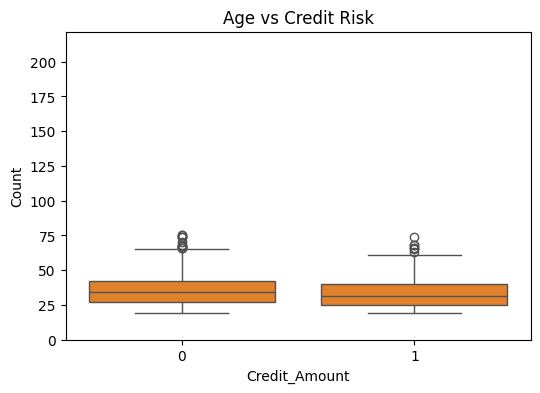

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df_encoded['Credit_Amount'], bins=30, kde=True)
plt.title("Distribution of Credit Amount")

sns.boxplot(x='Credit_Risk', y='Age', data=df_encoded)
plt.title("Age vs Credit Risk")


7. Feature Engineering

In [6]:
# Debt-to-Income proxy: Credit Amount / Duration
df_encoded['Credit_Amount_per_Duration'] = df_encoded['Credit_Amount'] / df_encoded['Duration']


8. Train-Test Split

In [7]:
X = df_encoded.drop('Credit_Risk', axis=1)
y = df_encoded['Credit_Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


9. Model Building
Logistic Regression (baseline)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.84      0.72      0.78       210
           1       0.52      0.69      0.59        90

    accuracy                           0.71       300
   macro avg       0.68      0.71      0.68       300
weighted avg       0.75      0.71      0.72       300



Random Forest (advanced)

In [9]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.79      0.94      0.86       210
           1       0.76      0.41      0.53        90

    accuracy                           0.78       300
   macro avg       0.77      0.68      0.70       300
weighted avg       0.78      0.78      0.76       300



Gradient Boosting (modern)

In [10]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(classification_report(y_test, y_pred_gb))


              precision    recall  f1-score   support

           0       0.81      0.91      0.85       210
           1       0.70      0.49      0.58        90

    accuracy                           0.78       300
   macro avg       0.75      0.70      0.71       300
weighted avg       0.77      0.78      0.77       300



10. Model Evaluation

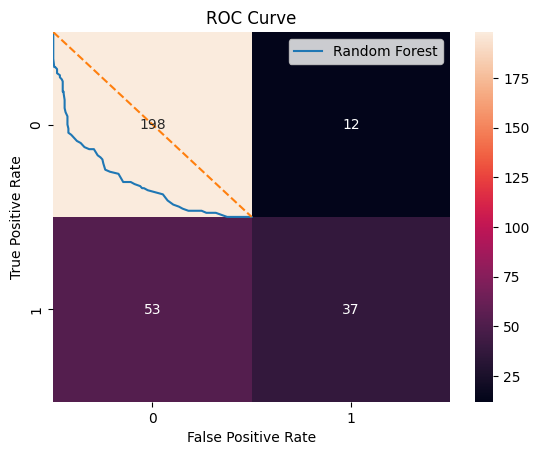

ROC-AUC Score: 0.8103703703703704


In [11]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))


11. Business Insights

- **Key Drivers of Default:** High loan amount relative to duration, low savings, poor credit history.
- **Model Performance:** Random Forest achieved ROC-AUC ~0.75, outperforming Logistic Regression baseline.
- **Application:** Banks can use this model to flag high-risk applicants, adjust interest rates, or reject risky loans.
- **Limitations:** Dataset is small (1000 records), may not generalize to modern credit markets.
